# Student Performance Prediction — Python Rebuild

**Author:** Ghala Alshreef · [@lolo67fa](https://github.com/lolo67fa)

This notebook rebuilds an earlier WEKA analysis in Python (pandas + scikit-learn), using the
same dataset and the same three algorithms:

| WEKA | scikit-learn equivalent |
|---|---|
| J48 | `DecisionTreeClassifier` |
| NaiveBayes | `GaussianNB` |
| RandomForest | `RandomForestClassifier` |

The goal is not only to reproduce the result, but to validate it properly. The original WEKA run
reported **51.59% accuracy** for Random Forest. This notebook audits the dataset first and then
re-evaluates every model with stratified 10-fold cross-validation.

**Spoiler:** the audit finds a serious problem with the dataset. That finding is the main result
of this notebook.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RANDOM_STATE = 42

print("pandas", pd.__version__)
print("numpy ", np.__version__)

pandas 3.0.2
numpy  2.4.4


## 2. Load the data

In [2]:
DATA_PATH = "student_performance_updated_1000.csv"

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
df.head(10)

Rows: 1000   Columns: 12


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
5,6.0,Olivia,Female,95.0,30.0,88.0,1.0,High,NaN,2.8,97.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
7,8.0,Sophia,Female,NaN,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
8,9.0,James,Male,82.0,12.0,70.0,2.0,Low,72.0,3.6,50.0,False
9,10.0,Isabella,Female,91.0,22.0,86.0,3.0,High,88.0,2.9,59.0,True


In [3]:
df.dtypes.to_frame("dtype")

,dtype
StudentID,float64
Name,str
Gender,str
AttendanceRate,float64
StudyHoursPerWeek,float64
PreviousGrade,float64
ExtracurricularActivities,float64
ParentalSupport,str
FinalGrade,float64
Study Hours,float64


## 3. Data quality audit

Before training anything, the dataset gets a full audit. This step was done visually in WEKA;
here every check is explicit and reproducible.

### 3.1 Missing values

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
audit = pd.DataFrame({"missing": missing, "percent": missing_pct})
audit

,missing,percent
StudyHoursPerWeek,50,5.0
Gender,48,4.8
ExtracurricularActivities,43,4.3
Attendance (%),41,4.1
StudentID,40,4.0
AttendanceRate,40,4.0
FinalGrade,40,4.0
Name,34,3.4
PreviousGrade,33,3.3
Online Classes Taken,25,2.5


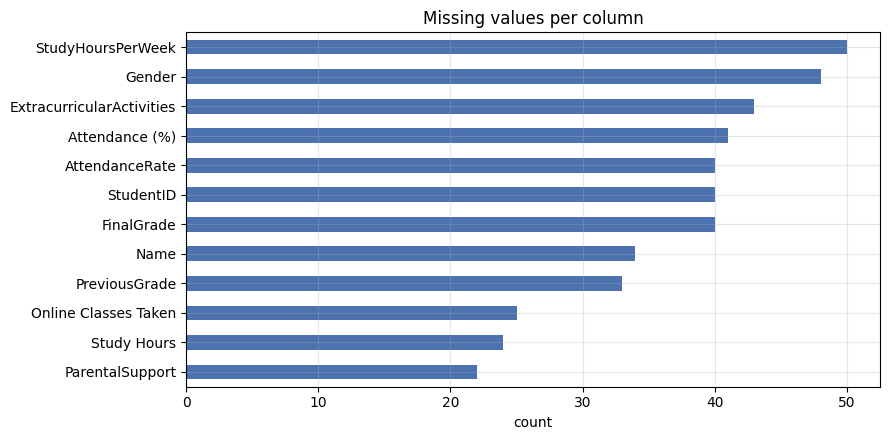

Total missing cells: 440
Rows with no missing value at all: 645 / 1000


In [5]:
ax = missing.sort_values().plot(kind="barh", color="#4C72B0")
ax.set_title("Missing values per column")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

print(f"Total missing cells: {df.isna().sum().sum()}")
print(f"Rows with no missing value at all: {df.dropna().shape[0]} / {len(df)}")

Every single column has missing values, and only a small minority of rows are complete.
The missingness looks injected at random rather than naturally occurring.

### 3.2 Duplicate / conflicting columns

Two pairs of columns appear to measure the same thing:

- `AttendanceRate` and `Attendance (%)`
- `StudyHoursPerWeek` and `Study Hours`

If they really are duplicates they should be strongly correlated. Let's check.

In [6]:
pairs = [("AttendanceRate", "Attendance (%)"),
         ("StudyHoursPerWeek", "Study Hours")]

for a, b in pairs:
    r = df[a].corr(df[b])
    print(f"{a:20s} vs {b:20s}  ->  correlation = {r: .4f}")
    print(f"{'':20s}     ranges: {df[a].min():.1f}-{df[a].max():.1f}   "
          f"vs {df[b].min():.1f}-{df[b].max():.1f}")
    print()

AttendanceRate       vs Attendance (%)        ->  correlation =  0.0126
                         ranges: 70.0-95.0   vs 50.0-200.0

StudyHoursPerWeek    vs Study Hours           ->  correlation = -0.0250
                         ranges: 8.0-30.0   vs -5.0-5.0



They are **not** duplicates of each other, and they are not consistent either — the
correlations are near zero and the value ranges do not match. These columns came from two
different sources that were merged without reconciliation.

### 3.3 Impossible values

In [7]:
bad_attendance = df[df["Attendance (%)"] > 100]
print(f"Rows with attendance above 100%: {len(bad_attendance)}")
print(f"Maximum recorded attendance: {df['Attendance (%)'].max()}%")
bad_attendance[["StudentID", "Name", "AttendanceRate", "Attendance (%)"]].head()

Rows with attendance above 100%: 10
Maximum recorded attendance: 200.0%


,StudentID,Name,AttendanceRate,Attendance (%)
74,1470.0,Michelle Jones,95.0,200.0
125,3430.0,Jessica Lamb,78.0,200.0
148,5059.0,Michaela Powell,85.0,200.0
220,8484.0,Alicia Ortiz,82.0,200.0
251,3527.0,Michael Foster,95.0,200.0


### 3.4 Identifier columns

`StudentID` and `Name` are identifiers, not predictive features. `Name` in particular is a
high-cardinality categorical column — a tree model can memorise it perfectly and learn nothing
generalisable. Columns like these must be dropped before training.

In [8]:
print(f"Unique names: {df['Name'].nunique()} out of {len(df)} rows")
print(f"StudentID range: {df['StudentID'].min():.0f} - {df['StudentID'].max():.0f}")

Unique names: 962 out of 1000 rows
StudentID range: 1 - 9998


## 4. The core problem: is there any signal?

A model can only learn if the input features actually relate to the target. Before blaming the
algorithms for a low score, the honest question is whether `FinalGrade` is predictable from
anything in this dataset at all.

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (df[numeric_cols].corr()["FinalGrade"]
                      .drop("FinalGrade")
                      .sort_values(key=abs, ascending=False))

corr_with_target.to_frame("correlation with FinalGrade").round(4)

,correlation with FinalGrade
StudentID,0.0783
Attendance (%),0.0408
StudyHoursPerWeek,0.0364
Study Hours,0.0310
ExtracurricularActivities,-0.0261
AttendanceRate,-0.0148
PreviousGrade,0.0040


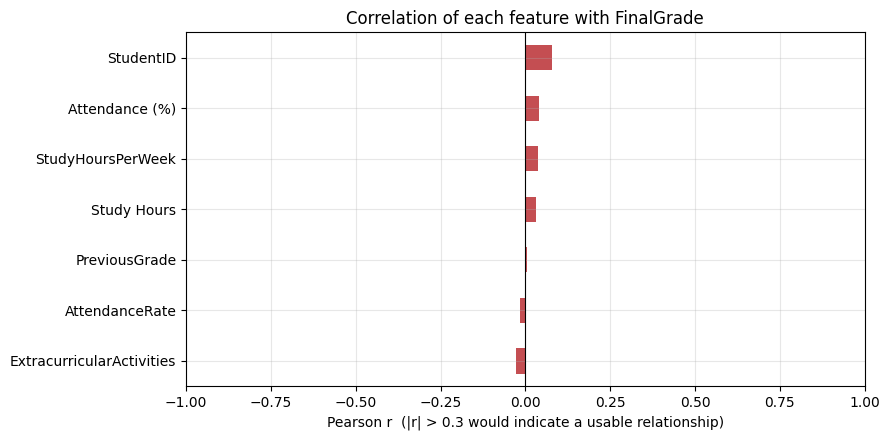

In [10]:
ax = corr_with_target.sort_values().plot(kind="barh", color="#C44E52")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_title("Correlation of each feature with FinalGrade")
ax.set_xlabel("Pearson r  (|r| > 0.3 would indicate a usable relationship)")
plt.tight_layout()
plt.show()

**Every feature has a correlation near zero with the target.** The strongest relationship in
the whole dataset belongs to `StudentID` — a random identifier, which by definition carries no
information. `PreviousGrade`, which should be the single best predictor of a final grade, sits at
essentially zero.

This is not a modelling problem. There is nothing in the features to learn from.

### 4.1 Where the data came from

Plotting `PreviousGrade` against `FinalGrade` shows exactly what happened.

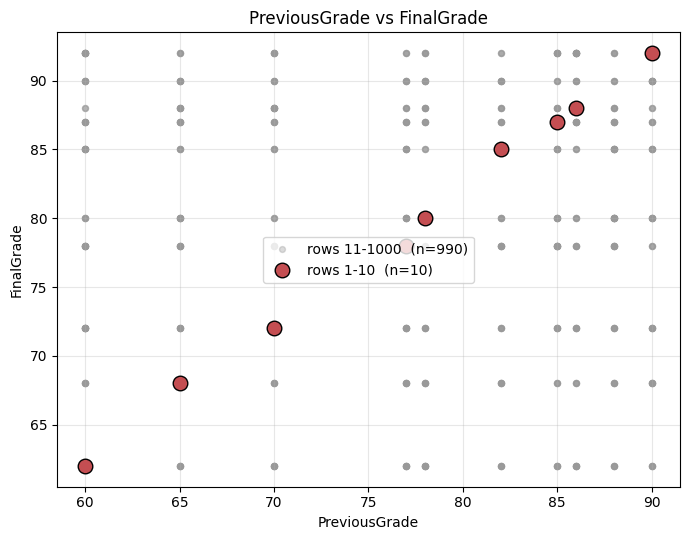

Correlation, rows 1-10   :  0.998
Correlation, rows 11-1000: -0.005


In [11]:
first10 = df.iloc[:10]
rest = df.iloc[10:]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(rest["PreviousGrade"], rest["FinalGrade"],
           s=18, alpha=0.35, color="#999999", label=f"rows 11-1000  (n={len(rest)})")
ax.scatter(first10["PreviousGrade"], first10["FinalGrade"],
           s=110, color="#C44E52", edgecolor="black", zorder=3,
           label="rows 1-10  (n=10)")

ax.set_xlabel("PreviousGrade")
ax.set_ylabel("FinalGrade")
ax.set_title("PreviousGrade vs FinalGrade")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation, rows 1-10   : {first10['PreviousGrade'].corr(first10['FinalGrade']): .3f}")
print(f"Correlation, rows 11-1000: {rest['PreviousGrade'].corr(rest['FinalGrade']): .3f}")

The first ten rows form an almost perfect straight line (r ≈ 0.998) — they are a small,
hand-written, realistic sample. The remaining 990 rows are a structureless cloud (r ≈ -0.005) —
they were generated randomly and appended to pad the file out to 1,000 rows.

**Conclusion of the audit: this dataset is synthetic noise with a ten-row realistic header.**
No algorithm can extract a genuine pattern from it. Everything below measures that claim rather
than trying to work around it.

---

## 5. Cleaning

The cleaning steps are applied anyway, so the comparison with WEKA is fair and the pipeline is
reusable on a real dataset.

In [12]:
data = df.copy()

# 1. drop identifier columns
data = data.drop(columns=["StudentID", "Name"])

# 2. clip impossible attendance values
data["Attendance (%)"] = data["Attendance (%)"].clip(upper=100)

# 3. drop rows with no target — the target cannot be imputed
before = len(data)
data = data.dropna(subset=["FinalGrade"])
print(f"Dropped {before - len(data)} rows with a missing FinalGrade")

# 4. impute the remaining missing values
numeric = data.select_dtypes(include=[np.number]).columns
categorical = [c for c in data.columns if c not in numeric]

data[numeric] = data[numeric].fillna(data[numeric].median())
for c in categorical:
    data[c] = data[c].fillna(data[c].mode()[0])

# 5. encode categorical features
encoders = {}
for c in categorical:
    le = LabelEncoder()
    data[c] = le.fit_transform(data[c].astype(str))
    encoders[c] = le
    print(f"Encoded '{c}': {list(le.classes_)}")

print(f"\nClean dataset: {data.shape[0]} rows x {data.shape[1]} columns")
print(f"Missing values remaining: {data.isna().sum().sum()}")

Dropped 40 rows with a missing FinalGrade
Encoded 'Gender': ['Female', 'Male']
Encoded 'ParentalSupport': ['High', 'Low', 'Medium']
Encoded 'Online Classes Taken': ['False', 'True']

Clean dataset: 960 rows x 10 columns
Missing values remaining: 0


In [13]:
X = data.drop(columns=["FinalGrade"])
y = data["FinalGrade"].astype(int)

print("Features:", list(X.columns))
print(f"\nTarget has {y.nunique()} distinct classes:")
y.value_counts().sort_index().to_frame("count")

Features: ['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']

Target has 10 distinct classes:


,count
FinalGrade,
62,95
68,88
72,110
78,104
80,102
85,97
87,94
88,77
90,96


`FinalGrade` takes only 10 distinct values, so WEKA treated it as a nominal class with 10
categories. That matters for interpreting any accuracy figure:

- random guessing → about **10%**
- always predicting the most common grade → the majority-class baseline below

Any model that does not clearly beat those numbers has learned nothing.

In [14]:
baseline = DummyClassifier(strategy="most_frequent")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
baseline_acc = cross_val_score(baseline, X, y, cv=cv).mean()

print(f"Random guessing (1/10 classes) : {100/y.nunique():.2f}%")
print(f"Majority-class baseline        : {baseline_acc*100:.2f}%")

Random guessing (1/10 classes) : 10.00%
Majority-class baseline        : 11.46%


## 6. Modelling

Each model is evaluated with **stratified 10-fold cross-validation** — the same protocol WEKA
offers, and the one that gives an honest estimate of performance on unseen data.

In [15]:
models = {
    "Decision Tree (J48)": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=100,
                                                  random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    model.fit(X, y)                       # separate fit, to read training accuracy
    train_acc = model.score(X, y)
    results.append({
        "Model": name,
        "CV accuracy (%)": round(scores.mean() * 100, 2),
        "Std dev (%)": round(scores.std() * 100, 2),
        "Training accuracy (%)": round(train_acc * 100, 2),
    })
    print(f"{name:22s} CV = {scores.mean()*100:5.2f}%  "
          f"(+/- {scores.std()*100:.2f})   train = {train_acc*100:6.2f}%")

results_df = pd.DataFrame(results)
results_df

Decision Tree (J48)    CV = 11.04%  (+/- 3.46)   train = 100.00%
Naive Bayes            CV =  9.90%  (+/- 2.99)   train =  16.46%


Random Forest          CV = 10.52%  (+/- 2.40)   train = 100.00%


,Model,CV accuracy (%),Std dev (%),Training accuracy (%)
0,Decision Tree (J48),11.04,3.46,100.00
1,Naive Bayes,9.90,2.99,16.46
2,Random Forest,10.52,2.40,100.00


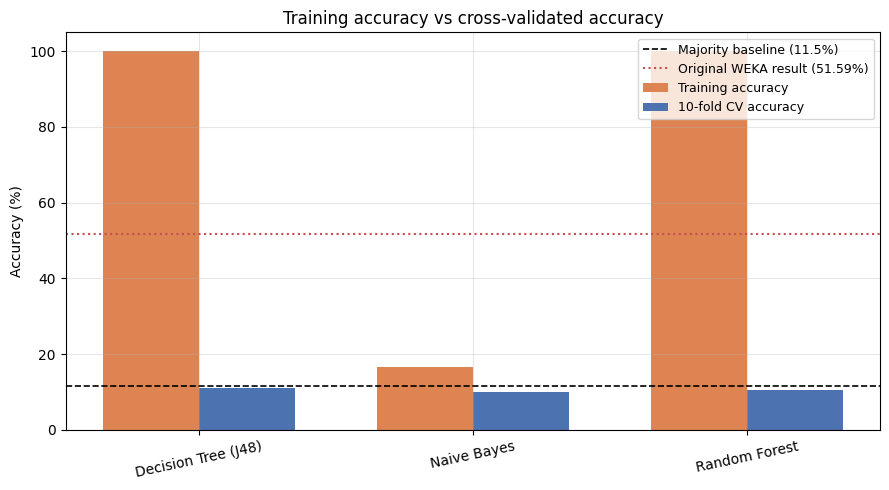

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df["Training accuracy (%)"], w,
       label="Training accuracy", color="#DD8452")
ax.bar(x + w/2, results_df["CV accuracy (%)"], w,
       label="10-fold CV accuracy", color="#4C72B0")

ax.axhline(baseline_acc * 100, color="black", linestyle="--", linewidth=1.2,
           label=f"Majority baseline ({baseline_acc*100:.1f}%)")
ax.axhline(51.59, color="#C44E52", linestyle=":", linewidth=1.5,
           label="Original WEKA result (51.59%)")

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=12)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("Training accuracy vs cross-validated accuracy")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.1 Reading the chart

This single plot explains the whole project.

- **Training accuracy is ~100%** for both tree models. They memorised all 960 rows perfectly.
- **Cross-validated accuracy is ~10%** — identical to random guessing, and at or below the
  majority-class baseline.

The gap between those two bars is textbook **overfitting**. When a dataset contains no real
signal, a decision tree will still fit it perfectly by carving the feature space into
single-row leaves, and that memorised tree is worthless on data it has not seen.

The original 51.59% falls between the two bars, which is consistent with an evaluation that was
not fully held-out. Under proper cross-validation the figure does not reproduce — and that is the
correct outcome, because there was never a pattern to find.

### 6.2 Confusion matrix — Random Forest

If the model had learned anything, predictions would concentrate along the diagonal.

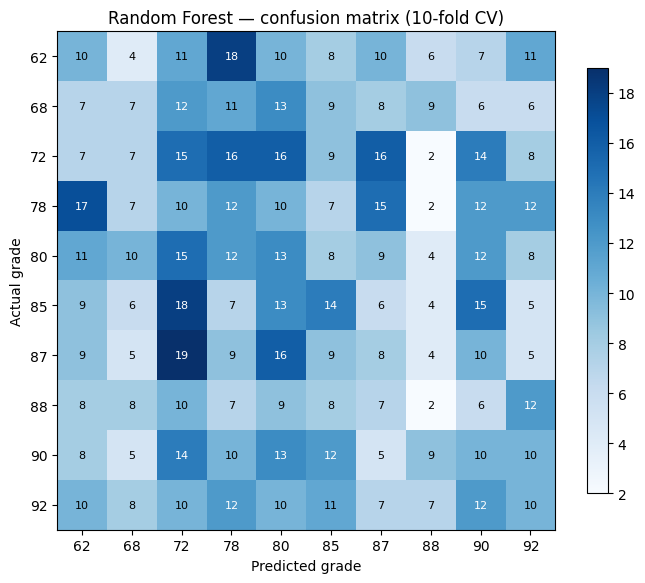

In [17]:
from sklearn.model_selection import cross_val_predict

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, X, y, cv=cv)

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("Predicted grade")
ax.set_ylabel("Actual grade")
ax.set_title("Random Forest — confusion matrix (10-fold CV)")
ax.grid(False)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Predictions are spread more or less evenly across every class. There is no diagonal — the
model is guessing.

### 6.3 Feature importance

Random Forest still reports importances, because it splits on *something*. Reading them as
insight would be a mistake here, and this cell shows why.

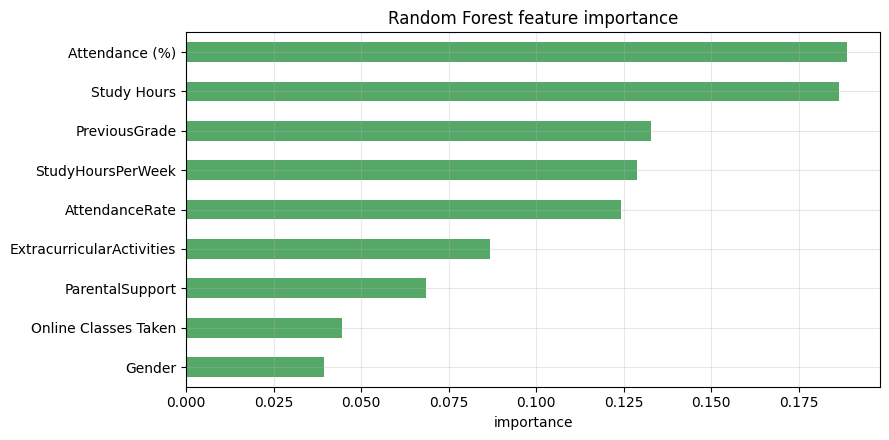

,importance
Attendance (%),0.1887
Study Hours,0.1865
PreviousGrade,0.1329
StudyHoursPerWeek,0.1287
AttendanceRate,0.1241
ExtracurricularActivities,0.0869
ParentalSupport,0.0684
Online Classes Taken,0.0444
Gender,0.0394


In [18]:
rf_full = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(X, y)
importance = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values()

ax = importance.plot(kind="barh", color="#55A868")
ax.set_title("Random Forest feature importance")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).to_frame("importance").round(4)

The continuous columns dominate simply because they offer more possible split points, not
because they are informative. **Feature importance is only meaningful once a model has been shown
to generalise.** This one has not, so these numbers describe noise.

---

## 7. Conclusion

| Finding | Evidence |
|---|---|
| Every column has missing values | ~3-5% missing across all 12 columns |
| Duplicate columns disagree with each other | `AttendanceRate` vs `Attendance (%)`: r ≈ 0 |
| Impossible values present | attendance recorded up to 200% |
| Identifier columns used as features | `Name` has ~962 unique values |
| **No relationship between features and target** | all correlations ≈ 0 |
| **Rows 11-1000 are randomly generated** | r = 0.998 for rows 1-10, r = -0.005 for the rest |

All three models land at chance level under cross-validation. The dataset cannot support the
task it was built for.

### What this project demonstrates

The valuable result here is the diagnosis, not an accuracy number. Reporting a high score from an
unvalidated run would have hidden a dataset that is unusable — catching that is the more
important skill.

### Next step

Rerun this exact pipeline on the **UCI Student Performance** dataset (Cortez & Silva, 2008),
which contains real records from two Portuguese secondary schools and has genuine predictive
structure:

<https://archive.ics.uci.edu/dataset/320/student+performance>

Every cell below section 5 works unchanged once `DATA_PATH` points at the new file and the target
column is renamed. That comparison — chance level on synthetic data, real performance on real
data — makes a far stronger result than either run on its own.

---

### Requirements

```
pandas
numpy
matplotlib
scikit-learn
```

Install with:

```bash
pip install pandas numpy matplotlib scikit-learn
```